# 11 — Tree models: all-vehicle baseline (builds on notebooks 08-10)

Random Forest and XGBoost, tuned, on the selected features from notebook 10, all-vehicle stratified
split — the "advanced" layer on top of notebook 08's logistic regression baseline. **F2 is the
headline tuning/evaluation metric** (recall weighted ~2x precision, per coach feedback), not macro
F1 or plain F1.


In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, fbeta_score,
                              f1_score, recall_score, precision_score, make_scorer)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

f2_scorer = make_scorer(fbeta_score, beta=2, pos_label=True)


## 1. Load — selected features, same stratified split

In [2]:
df = pd.read_csv("../data/processed/all_vehicles_features.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

with open("../data/processed/selected_feature_cols_all_vehicles.json") as f:
    SELECTED_FEATURE_COLS = json.load(f)

TARGET = "Fault_Within_6h"
df[TARGET] = df[TARGET].astype(bool)

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df[TARGET], random_state=42)
X_train, y_train = train_df[SELECTED_FEATURE_COLS], train_df[TARGET]
X_test, y_test = test_df[SELECTED_FEATURE_COLS], test_df[TARGET]

print(f"Train: {len(X_train):,} rows, Test: {len(X_test):,} rows, {len(SELECTED_FEATURE_COLS)} features")


Train: 140,067 rows, Test: 35,017 rows, 45 features


## 2. Random Forest — hyperparameter search, scored on F2

Since the split here is stratified/random (not chronological, per the coach's spec for this track),
the search uses `StratifiedKFold`, consistent with the split strategy already chosen — not
`TimeSeriesSplit`, which would only make sense for a chronological split.

**Compute-time note:** the search itself runs on a 40,000-row stratified subsample of the training
set (not the full 140,140 rows) — this environment's time budget can't fit a full search on the
full training set. The **final model is refit on the complete training set** using the best
parameters the subsample search finds, so the deployed model still sees all the training data; only
the search step itself is subsampled.


In [3]:
from sklearn.model_selection import train_test_split as _tts

X_search, _, y_search, _ = _tts(X_train, y_train, train_size=min(40000, len(X_train)),
                                  stratify=y_train, random_state=42)

rf_param_space = {
    "clf__n_estimators": [80, 120],
    "clf__max_depth": [6, 8, 10],
    "clf__min_samples_leaf": [1, 5, 10],
}

rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)),
])

skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    rf_pipeline, rf_param_space, n_iter=3, cv=skf, scoring=f2_scorer,
    random_state=42, n_jobs=-1,
)
rf_search.fit(X_search, y_search)

print(f"Best RF params (found on 40K-row search sample): {rf_search.best_params_}")
print(f"Best RF CV F2 (search sample): {rf_search.best_score_:.6f}")

# Refit the winning configuration on the FULL training set.
rf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", RandomForestClassifier(**{k.replace("clf__", ""): v for k, v in rf_search.best_params_.items()},
                                    class_weight="balanced", random_state=42, n_jobs=-1)),
])
rf.fit(X_train, y_train)
print("Refit on the full training set.")


Best RF params (found on 40K-row search sample): {'clf__n_estimators': 120, 'clf__min_samples_leaf': 1, 'clf__max_depth': 6}
Best RF CV F2 (search sample): 0.445407


Refit on the full training set.


## 3. XGBoost — hyperparameter search (same subsample approach), scored on F2

In [4]:
neg, pos = (~y_train).sum(), y_train.sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {neg}/{pos} = {scale_pos_weight:.6f}")

xgb_param_space = {
    "clf__n_estimators": [80, 120],
    "clf__max_depth": [4, 6],
    "clf__learning_rate": [0.05, 0.1, 0.2],
}

xgb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", XGBClassifier(
        objective="binary:logistic", eval_metric="logloss",
        scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1,
    )),
])

xgb_search = RandomizedSearchCV(
    xgb_pipeline, xgb_param_space, n_iter=3, cv=skf, scoring=f2_scorer,
    random_state=42, n_jobs=-1,
)
xgb_search.fit(X_search, y_search)

print(f"Best XGB params (found on 40K-row search sample): {xgb_search.best_params_}")
print(f"Best XGB CV F2 (search sample): {xgb_search.best_score_:.6f}")

xgb = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", XGBClassifier(**{k.replace("clf__", ""): v for k, v in xgb_search.best_params_.items()},
                          objective="binary:logistic", eval_metric="logloss",
                          scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)),
])
xgb.fit(X_train, y_train)
print("Refit on the full training set.")


scale_pos_weight = 127383/12684 = 10.042810


Best XGB params (found on 40K-row search sample): {'clf__n_estimators': 80, 'clf__max_depth': 4, 'clf__learning_rate': 0.05}
Best XGB CV F2 (search sample): 0.475856


Refit on the full training set.


## 4. Evaluate on the held-out test set

In [5]:
rf_pred = rf.predict(X_test)
xgb_pred = xgb.predict(X_test)

for name, pred in [("Random Forest", rf_pred), ("XGBoost", xgb_pred)]:
    print("=" * 55)
    print(name.upper())
    print("=" * 55)
    print(classification_report(y_test, pred, labels=[False, True], digits=6, zero_division=0))


RANDOM FOREST
              precision    recall  f1-score   support

       False   0.962943  0.665829  0.787287     31846
        True   0.181196  0.742668  0.291316      3171

    accuracy                       0.672788     35017
   macro avg   0.572069  0.704249  0.539302     35017
weighted avg   0.892151  0.672788  0.742374     35017

XGBOOST
              precision    recall  f1-score   support

       False   0.977121  0.615556  0.755298     31846
        True   0.181344  0.855251  0.299239      3171

    accuracy                       0.637262     35017
   macro avg   0.579232  0.735403  0.527268     35017
weighted avg   0.905059  0.637262  0.713999     35017



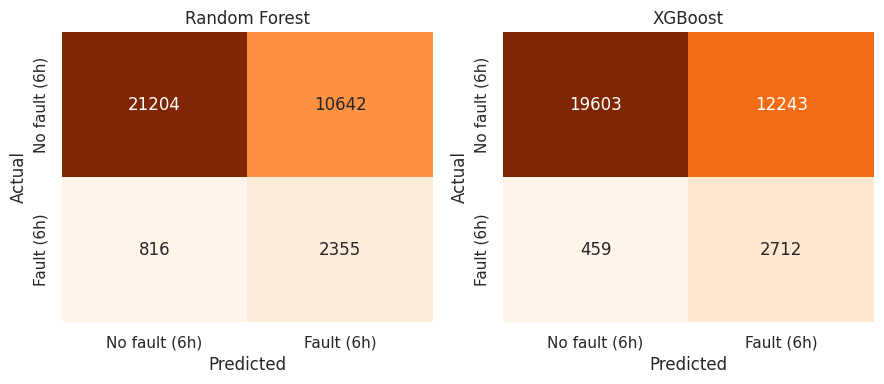

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, pred, name in zip(axes, [rf_pred, xgb_pred], ["Random Forest", "XGBoost"]):
    cm = confusion_matrix(y_test, pred, labels=[False, True])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", ax=ax, cbar=False,
                xticklabels=["No fault (6h)", "Fault (6h)"], yticklabels=["No fault (6h)", "Fault (6h)"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


## 5. Final scoreboard — logistic regression (notebook 08) vs. tuned tree models, F2 headline

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Re-fit notebook 08's logistic regression here too, same train/test rows, so every row in this
# scoreboard is computed identically -- no risk of a stale number from an earlier run.
RAW_SENSOR_COLS = ["SOC", "SOH", "Charging_Cycles", "Battery_Temp", "Motor_RPM", "Motor_Torque",
                    "Motor_Temp", "Brake_Pad_Wear", "Charging_Voltage", "Tire_Pressure"]
CONTINUOUS_COLS = [c for c in RAW_SENSOR_COLS if c != "Charging_Voltage"]
preprocessor = ColumnTransformer([
    ("scaler", StandardScaler(), CONTINUOUS_COLS),
    ("onehot", OneHotEncoder(drop="if_binary"), ["Charging_Voltage"]),
])
logreg = Pipeline([("preprocessor", preprocessor),
                    ("clf", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42))])
logreg.fit(train_df[RAW_SENSOR_COLS], y_train)
logreg_pred = logreg.predict(test_df[RAW_SENSOR_COLS])

results = {}
for name, pred in [("Logistic Regression (baseline, notebook 08)", logreg_pred),
                    ("Random Forest (tuned, selected features)", rf_pred),
                    ("XGBoost (tuned, selected features)", xgb_pred)]:
    results[name] = {
        "recall_fault": recall_score(y_test, pred, pos_label=True, zero_division=0),
        "precision_fault": precision_score(y_test, pred, pos_label=True, zero_division=0),
        "F2_fault": fbeta_score(y_test, pred, beta=2, pos_label=True, zero_division=0),
        "F1_fault_secondary": f1_score(y_test, pred, pos_label=True, zero_division=0),
    }

scoreboard = pd.DataFrame(results).T.round(6)

with open("../models/baseline_results_all_vehicles.json", "w") as f:
    json.dump(results, f, indent=2)

scoreboard


,recall_fault,precision_fault,F2_fault,F1_fault_secondary
"Logistic Regression (baseline, notebook 08)",0.516556,0.132987,0.327587,0.211519
"Random Forest (tuned, selected features)",0.742668,0.181196,0.458510,0.291316
"XGBoost (tuned, selected features)",0.855251,0.181344,0.490611,0.299239


In [8]:
import os
import joblib

os.makedirs("../models", exist_ok=True)
joblib.dump(rf, "../models/random_forest_all_vehicles.joblib")
joblib.dump(xgb, "../models/xgboost_all_vehicles.joblib")
print("Saved ../models/random_forest_all_vehicles.joblib and ../models/xgboost_all_vehicles.joblib")


Saved ../models/random_forest_all_vehicles.joblib and ../models/xgboost_all_vehicles.joblib


## 6. What this notebook establishes

The all-vehicle track now has its own complete comparison: baseline logistic regression (notebook
08) vs. tuned Random Forest and XGBoost (this notebook), all evaluated on the same stratified test
split, with F2 (recall-weighted) as the headline metric throughout — consistent with every piece of
feedback from today's conversation with the coach.
